In [194]:
import numpy as np
import simulate_data as sim
from importlib import reload
reload(sim)
import pandas as pd
import matplotlib.pyplot as plt

In [135]:
from scipy.stats import norm
from scipy.special import log_ndtr

def inv_mills_ratio(z, upper=False):
    """
    Odwrotny Mills ratio: pdf(z) / cdf(z) (lub / (1-cdf(z)) dla upper=True),
    liczony numerycznie stabilnie.
    """
    if upper:
        return np.exp(norm.logpdf(z) - log_ndtr(-z))
    return np.exp(norm.logpdf(z) - log_ndtr(z))

Censored low: 500  |  uncensored: 3500  |  Censored high: 1000


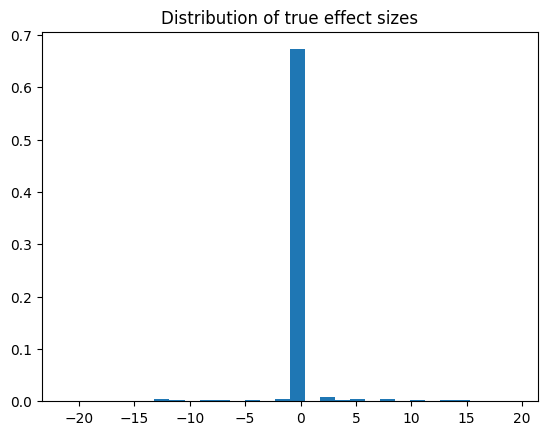

In [188]:
###simulate data
rng= np.random.default_rng(42)

n, d = 5_000, 500
l_perc, u_perc = 10, 80
r2 = 0.5
snr = r2/(1-r2)
perc_sig = 0.1

X = sim.X_corr_blocks(n, d, k = 5, corr =0.9, seed = 42, intercept = False)
beta_true = sim.beta_sparse(d, beta_scale, perc_sig, seed = 42)
y, l, u, sigma_y_true, snr= sim.y_tobit_2(X, l_perc, u_perc, beta_true, snr = snr, seed=42)

mask_l   = (y == l)
mask_u   = (y == u)
mask_mid = ~mask_l & ~mask_u

print(f"Censored low: {mask_l.sum()}  |  uncensored: {mask_mid.sum()}  |  Censored high: {mask_u.sum()}")

plt.hist(beta_true, bins =30, density = True)
plt.title("Distribution of true effect sizes")
plt.show()

In [189]:
from scipy.stats import invgamma, norm
from scipy.special import logit, expit

### define prior

tau2 = 25
pi0 = 0.1
delta, eps = 0.01, 0.01

### setup

n_iter = 2_000
n,d = X.shape
l = np.min(y) if (y == np.min(y)).sum() > 5 else -np.inf
u = np.max(y) if (y == np.max(y)).sum() > 5 else np.inf

### initialize parameters

rng = np.random.default_rng(32)
a = delta + n/2
b = a

G = X.T @ X
XtX_diag = np.diag(G)
logit_pi0 = logit(pi0)

beta0 = rng.normal(0,tau2, d)
rho = rng.uniform(0,1,d)
P = np.diag(rho)
R = G * (P @ (np.eye(d) - P) + np.outer(rho, rho))

eta = X @ P @ beta0
nu = b/a


z_l = (l - eta[mask_l]) / nu
z_u = (u - eta[mask_u]) / nu

lambda_l = inv_mills_ratio(z_l)
lambda_u = inv_mills_ratio(z_u, upper=True)

# --- mu ---
mu = np.empty_like(eta, dtype=float)
mu[mask_mid] = y[mask_mid]
mu[mask_l] = eta[mask_l] - nu * lambda_l
mu[mask_u] = eta[mask_u] + nu * lambda_u

# --- Sigma_ii ---
Sigma_ii = np.zeros_like(eta, dtype=float)
Sigma_ii[mask_l] = nu**2 * (1 - lambda_l * (lambda_l - z_l))
Sigma_ii[mask_u] = nu**2 * (1 - lambda_u * (lambda_u + z_u))

In [190]:
rng = np.random.default_rng(32)
a = delta + n/2
b = a
G = X.T @ X
XtX_diag = np.diag(G)
logit_pi0 = logit(pi0)
beta0 = rng.normal(0, tau2, d)
rho = rng.uniform(0, 1, d)          # <- poprawione: (0,1) zamiast (0,2)

R = G * np.outer(rho, rho)
np.fill_diagonal(R, XtX_diag * rho)  # <- P diagonalna, bez pełnego P@(I-P)

eta = X @ (rho * beta0)              # <- odpowiednik X@P@beta0 dla P diagonalnej
nu = np.sqrt(b/a)                    # <- poprawione: pierwiastek

z_l = (l - eta[mask_l]) / nu
z_u = (u - eta[mask_u]) / nu
lambda_l = inv_mills_ratio(z_l)
lambda_u = inv_mills_ratio(z_u, upper=True)

mu = np.empty_like(eta, dtype=float)
mu[mask_mid] = y[mask_mid]
mu[mask_l] = eta[mask_l] - nu * lambda_l
mu[mask_u] = eta[mask_u] + nu * lambda_u

Sigma_ii = np.zeros_like(eta, dtype=float)
Sigma_ii[mask_l] = nu**2 * (1 - lambda_l * (lambda_l - z_l))
Sigma_ii[mask_u] = nu**2 * (1 - lambda_u * (lambda_u + z_u))

pbar = tqdm(range(n_iter), desc="MFVI")
for it in pbar:
    # q(beta)
    S = np.linalg.inv(a/b * R + 1/tau2 * np.eye(d))
    S_diag = np.diag(S)
    m = (a/b) * S @ (rho * (X.T @ mu))   # P@X.T@mu -> rho*(X.T@mu), P diagonalna

    # q(y_latent)
    eta = X @ (rho * m)
    nu = np.sqrt(b/a)                     # <- poprawione

    z_l = (l - eta[mask_l]) / nu           # <- teraz aktualizowane co iterację
    z_u = (u - eta[mask_u]) / nu
    lambda_l = inv_mills_ratio(z_l)
    lambda_u = inv_mills_ratio(z_u, upper=True)

    mu[mask_l] = eta[mask_l] - nu * lambda_l
    mu[mask_u] = eta[mask_u] + nu * lambda_u

    Sigma_ii[mask_l] = nu**2 * (1 - lambda_l * (lambda_l - z_l))
    Sigma_ii[mask_u] = nu**2 * (1 - lambda_u * (lambda_u + z_u))

    # q(gamma)
    resid_base = mu - eta
    Xt_resid_base = X.T @ resid_base
    correction = rho * m * XtX_diag

    linear_term = (a / b) * m * (Xt_resid_base + correction)
    quad_term = (a / (2 * b)) * (m**2 + S_diag) * XtX_diag

    rho = expit(logit_pi0 - quad_term + linear_term)

    # aktualizacja R po zmianie rho
    R = G * np.outer(rho, rho)
    np.fill_diagonal(R, XtX_diag * rho)

    # q(sigma)
    trace_RS = np.sum(R * S)
    b = eps + 0.5 * (
        np.sum(Sigma_ii + mu**2)
        - 2 * m @ (rho * (X.T @ mu))
        + trace_RS
        + m @ R @ m
    )

MFVI:   0%|          | 0/2000 [00:00<?, ?it/s]

[]

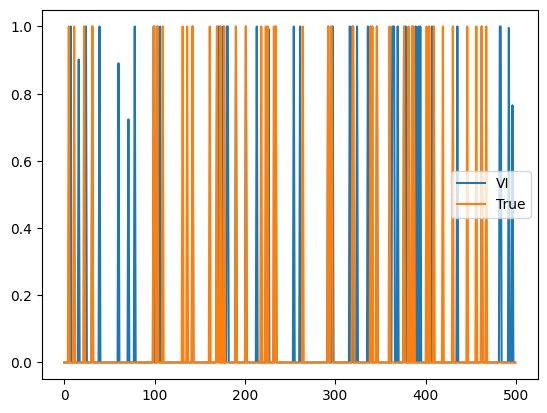

In [191]:
sig_true = beta_true !=0
sig_vi = rho > 0.95

plt.plot(rho, label = "VI")
plt.plot(sig_true, label = "True")
plt.legend()
plt.plot()

In [192]:
TP = (sig_true & sig_vi).sum()
TN =( (~sig_true) & (~sig_vi)).sum()
FP = ((~sig_true) & sig_vi).sum()
FN = (sig_true & (~sig_vi)).sum()

precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan          # PPV
recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan          # sensitivity/power
specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan          # 1 - FPR
npv         = TN / (TN + FN) if (TN + FN) > 0 else np.nan
fdr         = FP / (TP + FP) if (TP + FP) > 0 else np.nan          # false discovery rate
fpr         = FP / (FP + TN) if (FP + TN) > 0 else np.nan
fnr         = FN / (FN + TP) if (FN + TP) > 0 else np.nan
accuracy    = (TP + TN) / n
f1          = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else np.nan

# Matthews Correlation Coefficient - dobra miara zbiorcza przy niezbalansowanych klasach
mcc_denom = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
mcc = (TP*TN - FP*FN) / mcc_denom if mcc_denom > 0 else np.nan

stats = pd.DataFrame({
    "Metryka": ["Precision (PPV)", "Recall (Power/Sensitivity)", "Specificity",
                "NPV", "FDR", "FPR", "FNR", "Accuracy", "F1-score", "MCC"],
    "Wartość": [precision, recall, specificity, npv, fdr, fpr, fnr, accuracy, f1, mcc]
})
stats["Wartość"] = stats["Wartość"].round(3)

confusion = pd.DataFrame(
    [[TP, FN], [FP, TN]],
    index=["Rzeczywisty: istotny", "Rzeczywisty: nieistotny"],
    columns=["Predykcja: istotny", "Predykcja: nieistotny"]
)

print(confusion)
print()
print(stats.to_string(index=False))

                         Predykcja: istotny  Predykcja: nieistotny
Rzeczywisty: istotny                     15                     30
Rzeczywisty: nieistotny                  31                    424

                   Metryka  Wartość
           Precision (PPV)    0.326
Recall (Power/Sensitivity)    0.333
               Specificity    0.932
                       NPV    0.934
                       FDR    0.674
                       FPR    0.068
                       FNR    0.667
                  Accuracy    0.088
                  F1-score    0.330
                       MCC    0.263


In [193]:
import numpy as np
import pandas as pd

def block_confusion_stats(sig_true, sig_vi, k):
    """
    Statystyki na poziomie bloków skorelowanych zmiennych.
    Blok uznaje się za:
      - true-positive block: zawiera >=1 prawdziwy sygnał ORAZ >=1 wybraną zmienną
      - false-negative block: zawiera >=1 prawdziwy sygnał, ale ŻADNA zmienna nie została wybrana
      - false-positive block: nie zawiera sygnału, ale >=1 zmienna została wybrana
      - true-negative block: nie zawiera sygnału i żadna zmienna nie została wybrana
    """
    d = len(sig_true)
    assert d % k == 0, "d musi być podzielne przez k"
    n_blocks = d // k

    sig_true_b = sig_true.reshape(n_blocks, k)
    sig_vi_b   = sig_vi.reshape(n_blocks, k)

    block_has_true = sig_true_b.any(axis=1)   # (n_blocks,) - czy blok zawiera sygnał
    block_has_vi   = sig_vi_b.any(axis=1)     # (n_blocks,) - czy cokolwiek z bloku wybrano

    TP = (block_has_true & block_has_vi).sum()
    TN = ((~block_has_true) & (~block_has_vi)).sum()
    FP = ((~block_has_true) & block_has_vi).sum()
    FN = (block_has_true & (~block_has_vi)).sum()

    return TP, TN, FP, FN, n_blocks


def compute_stats(TP, TN, FP, FN):
    n = TP + TN + FP + FN
    precision   = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall      = TP / (TP + FN) if (TP + FN) > 0 else np.nan
    specificity = TN / (TN + FP) if (TN + FP) > 0 else np.nan
    npv         = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    fdr         = FP / (TP + FP) if (TP + FP) > 0 else np.nan
    fpr         = FP / (FP + TN) if (FP + TN) > 0 else np.nan
    fnr         = FN / (FN + TP) if (FN + TP) > 0 else np.nan
    accuracy    = (TP + TN) / n if n > 0 else np.nan
    f1          = 2*precision*recall/(precision+recall) if (precision+recall) > 0 else np.nan
    mcc_denom   = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    mcc         = (TP*TN - FP*FN) / mcc_denom if mcc_denom > 0 else np.nan

    stats = pd.DataFrame({
        "Metryka": ["Precision (PPV)", "Recall (Power/Sensitivity)", "Specificity",
                    "NPV", "FDR", "FPR", "FNR", "Accuracy", "F1-score", "MCC"],
        "Wartość": [precision, recall, specificity, npv, fdr, fpr, fnr, accuracy, f1, mcc]
    })
    stats["Wartość"] = stats["Wartość"].round(3)

    confusion = pd.DataFrame(
        [[TP, FN], [FP, TN]],
        index=["Rzeczywisty: istotny", "Rzeczywisty: nieistotny"],
        columns=["Predykcja: istotny", "Predykcja: nieistotny"]
    )
    return confusion, stats


# --- użycie ---
k = 5  # rozmiar bloku - dopasuj do struktury korelacji w X
TP, TN, FP, FN, n_blocks = block_confusion_stats(sig_true, sig_vi, k)
confusion, stats = compute_stats(TP, TN, FP, FN)

print(f"Liczba bloków: {n_blocks} (rozmiar bloku k={k})")
print(confusion)
print()
print(stats.to_string(index=False))

Liczba bloków: 100 (rozmiar bloku k=5)
                         Predykcja: istotny  Predykcja: nieistotny
Rzeczywisty: istotny                     26                     14
Rzeczywisty: nieistotny                  10                     50

                   Metryka  Wartość
           Precision (PPV)    0.722
Recall (Power/Sensitivity)    0.650
               Specificity    0.833
                       NPV    0.781
                       FDR    0.278
                       FPR    0.167
                       FNR    0.350
                  Accuracy    0.760
                  F1-score    0.684
                       MCC    0.493
